# Extracting hidden behavioral states from choice data (replication of Ashwood et al., 2023)

In this notebook, we will show how to use choice data to derive hidden behavioral states using the NeMoS GLM-HMM implementation. We will use Nemos' Bernoulli GLM-HMM to model mice choices and extract their hidden behavioral states during a decision making task. As a result, we will replicate the previously published results from Ashwood et al. (2023). 

We have two main goals for this notebook:

1. Show how to use NeMoS to fit GLM-HMMs to choices
2. Show how to interpret GLM-HMM fitting results 
1. Demonstrate replication of previously published results using NeMoS

Importantly, throughout the notebook we will assume you already have a solid theoretical understanding of GLMs and GLM-HMMs. If you need a refresher, please refer to our tutorial on GLMs and GLM-HMMs. Moreover, if you already have a good understanding of GLM-HMMs and are interested in different heuristics you could use to overcome difficulties in the fitting process, please refer to our tutorial for fine-grain details of the fitting algorithm and different initialization methods you could use to ensure the best possible fit and thus description of your data under this model.

## Setup

In [16]:
# Imports
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import nemos as nmo
import pynapple as nap

from notebook_utils import *

seed = 0  # Random seed for reproducibility
np.random.seed(seed)
jax.config.update("jax_enable_x64", True)

## Download and preprocessing of data
Normally, when importing an IBL dataset, you should follow this process:
XX
However, since we are interested in reproducing a particular set of figures, we will retrieve the already preprocessed data of a single mouse. If you are interested in understanding how this preprocessing took place, please refer to [ashwood's repo]

In [23]:
io = nmo.fetch.download_dandi_data(
    "000045",
    "sub-00778394-c956-408d-8a6c-ca3b05a611d5_ses-00594aec-bb70-4601-862d-63a31ef0e1c0_behavior+image.nwb"
)

ImportError: Missing optional dependency 'dandi'. Please use pip or conda to install 'dandi'.

In [ ]:
input, y_raw, session = load_data("IBL/CSHL_008_processed.npz")

X_mouse = input # In the real paper there were 3 inputs: stimuli, prev choice, wsls

# Choices
choices_mouse = y_raw.flatten() # Convert to (n_timepoints,)

# new_sess array
# Create array of 1s and 0s marking session boundaries
new_sess_mouse = np.zeros(len(session), dtype=int)
new_sess_mouse[0] = 1  # First entry is always 1

# Mark where session changes
new_sess_mouse[1:] = (session[1:] != session[:-1]).astype(int)
new_sess_mouse

## 01. Understanding the task structure: IBL decision-making task

<center><img src="images/IBL_edited.png" alt="Task schematic" width="500" /></center>

<div style="text-align: center;">

  Task illustration. Modified from IBL et al. (2021) 
   <span id="cite1a"></span><a href="#ref1">[1a]</a>.
</div>

We will analyze the IBL decision-making task, which is a variation of the two-alternative forced-choice perceptual detection task (IBL et al., 2021 <span id="cite1b"></span><a href="#ref1">[1b]</a>). During this task, a sinusoidal grating with varying contrast [0\%-100\%] appeared either at the right or left side of the screen. The goal for the mice was to indicate this side turning a little wheel so that this turn would accordingly move the stimuli to the center of the screen (Burgess et al. (2021) <span id="cite2a"></span><a href="#ref2">[2]</a>. If the mice chose the side correctly, they would receive a water reward; if not, a noise burst and there would be a 1 second timeout. 

For the first 90 trials of each session, the stimulus appeared randomly on either side of the screen; after that, the stimulus would appear on one side with fixed probability 0.8 and alternate randomly every 20-100 trials. Same as in Ashwood et al., (2023)  <span id="cite1c"></span><a href="#ref1">[1c]</a>., we will only analyze the first 90 trials of each session (the ones with random appearance at either side).

In [18]:
new_sess_pos = np.array(np.where(new_sess_mouse==1))
sess_length = np.array(np.where(new_sess_mouse==1))[0][1] - 1 # substracting the starting trial

choices_tsd = nap.Tsd(t = np.arange(choices_mouse.shape[0]), d=choices_mouse, time_support=nap.IntervalSet(start=new_sess_pos, end = new_sess_pos+ sess_length))

true_initial_prob = jnp.array([0.95, 0.025, 0.025])

# Initial guess - Initial prob
initial_prob_initial_guess_mouse = true_initial_prob

true_intercept = np.array(
    [1, -3, 3],dtype=float  # Bias - Intercept
)
# Transition matrix
true_transition_prob = np.array(
    [[0.98, 0.01, 0.01], [0.04, 0.94, 0.02], [0.04, 0.01, 0.96]]
)

# True mouse projection weights
X_labels_mouse = ["bias", "stimulus", "Prev.choice", "WSLS"]

projection_weights_true_values_mouse = np.array(
    [
        [6, 2, 2],      # Stimulus,
        [-.1, .1, .2],  # Previous choice
        [-.1, .1, .2]  # Win-stay, lose-switch
        
    ]
    , dtype=float  
)
projection_weights_initial_guess_mouse = projection_weights_true_values_mouse

# True mouse intercept

true_intercept_mouse = true_intercept 
intercept_initial_guess_mouse = true_intercept_mouse

true_transition_prob_mouse = true_transition_prob
transition_prob_initial_guess_mouse = true_transition_prob_mouse
# High proba in diagonal - low elsewhere
#transition_prob_initial_guess_mouse = np.ones(true_transition_prob.shape) * 0.05
#transition_prob_initial_guess_mouse[np.diag_indices(true_transition_prob.shape[1])] = 0.9

model = nmo.glm_hmm.GLMHMM(3)
model.fit(X_mouse, choices_mouse)


,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...t 0x13385dee0>
,regularizer,UnRegularized()
,regularizer_strength,None
,dirichlet_prior_alphas_init_prob,None
,dirichlet_prior_alphas_transition,None
,solver_name,'GradientDescent'
,solver_kwargs,{}
,initialization_funcs,"{'glm_params_init': <function ran...t 0x133fdc360>, 'initial_proba_init': <function uni...t 0x1345d6d40>, 'scale_init': <function one...t 0x1345d6840>, 'transition_proba_init': <function sti...t 0x1345d6660>}"
,maxiter,1000


how do i make this reset 

Animals don't do 3000 trials at once! Instead, they generally do several sessions of 100-300 trials. We use all the sessions together to fit our model. For our model to be accurate, we need to tell it when our session boundaries are: we don't want it to compute two different sessions as if they were one. 

NeMos computes NaNs either in the input matrix X or in the choice vector y as new sessions

!! careful, if your choice data contains nan values, they will be handled as new sessions, so make sure to address this promptly

In our case, we are safe from this issue because we are using Pynapple to handle our session information

First I'll initialize with the real ones just for testing then I'll do random noise centered in real values I think

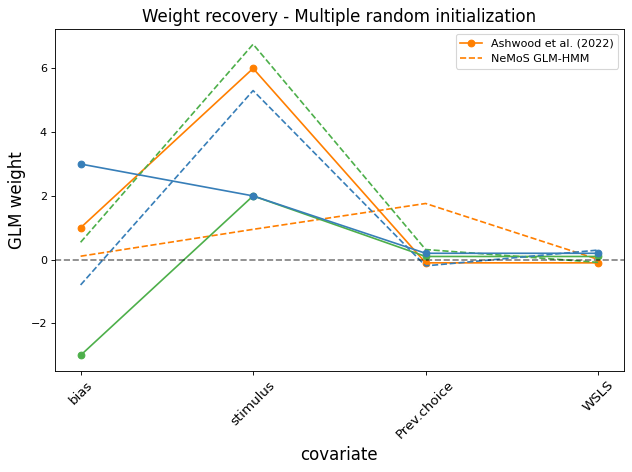

In [19]:
# Stack array for plotting
stacked_arr = np.vstack([true_intercept_mouse, projection_weights_true_values_mouse])
stacked_arr

plot_glm_weights(
    model.coef_.shape[0]+ 1,
    3, # n states
    stacked_arr,
    model.intercept_,
    model.coef_,
    X_labels_mouse,
    "Multiple random initialization",
    )


in principle, the reason why this looks off is that we are using different data.

Pending to test whether the likelihood of the recovered parameters is lower or larger than the likelihood of the paper's?

plot 

NameError: name 'n_states' is not defined

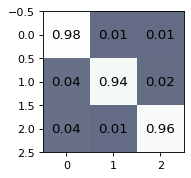

In [20]:
fig = plt.figure(figsize=(5, 2.5), dpi=80, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)
gen_trans_mat = true_transition_prob_mouse
plt.imshow(gen_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(gen_trans_mat.shape[0]):
    for j in range(gen_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(gen_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.ylim(n_states - 0.5, -0.5)
plt.ylabel("state t", fontsize = 15)
plt.xlabel("state t+1", fontsize = 15)
plt.title("generative", fontsize = 15)


plt.subplot(1, 2, 2)
recovered_trans_mat = np.exp(log_transition_matrix)
plt.imshow(recovered_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(recovered_trans_mat.shape[0]):
    for j in range(recovered_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(recovered_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, n_states), ('1', '2', '3'), fontsize=10)
plt.ylim(n_states - 0.5, -0.5)
plt.title("recovered", fontsize = 15)
plt.subplots_adjust(0, 0, 1, 1)

## 02. Understanding fitting: Hierarchical fitting process
Explanation of Ashwood fitting process.

I think it would be nice to showcase a small version of the hierarchical fitting process here, only because people using the tool might be interested in running similar analyses

## 03. Fitting the data
- Plot state probability against choices to show that in the state in which the animal considers the stimuli it performs better

## 04. Comparing results
1. Show weights, initial and transition proba recoveries
2. Show log likelihood
2. Benchmark with ssm

## Conclusion

## Other resources

## References

<a id="ref1"></a><a href="#cite1a">[1a]</a> <a href="#cite1b">[1b]</a> <a href="#cite1c">[1c]</a> <a href="#cite1d">[1d]</a> Pillow, J. W., Shlens, J., Paninski, L., Sher, A., Litke, A. M., Chichilnisky, E. J., & Simoncelli, E. P. (2008). Spatio-temporal correlations and visual signalling in a complete neuronal population. Nature, 454(7207), 995-999. https://doi.org/10.1038/nature07140

## Other scripts (to be removed)

### Reproducing error of using a Pynapple object for choice data
when both are different lengths it breaks even though it shouldnt.
error: my choices are not a valid jax type

In [ ]:
# Error reproduction
# Stimuli shown to the "mice"
stim_vals = [-1, -0.5, -0.25, -0.125,
    -0.0625, 0, 0.0625, 0.125, 0.25, 0.5, 1,
]

# Generate random sequence of stimuli for simulation - this design matrix is stupid because its the stimuli repeated three times
X = np.random.choice(stim_vals, (5040,3))

# Session starts
new_sess_rand_pos =  np.array([0,   90,  180,  270,  360,  450,  540,  630,  720,  810,  900,
         990, 1080, 1170, 1260, 1350, 1440, 1530, 1620, 1710, 1800, 1890,
        1980, 2070, 2160, 2250, 2340, 2430, 2520, 2610, 2700, 2790, 2880,
        2970, 3060, 3150, 3240, 3330, 3420, 3510, 3600, 3690, 3780, 3870,
        3960, 4050, 4140, 4230, 4320, 4410, 4500, 4590, 4680, 4770, 4860,
        4950])
# Session lengths
sess_rand_length = new_sess_rand_pos[1] - 1 # substracting the starting trial

# Set up rand choices
choices_mouse_rand = np.random.choice([0,1], 5040)

# Set up Tsd with choices with timesupport corresponding to epochs
choices_rand_tsd = nap.Tsd(t = np.arange(choices_mouse_rand.shape[0]), d=choices_mouse_rand, time_support=nap.IntervalSet(start=new_sess_rand_pos, end = new_sess_rand_pos + sess_rand_length))

# Initialize and fit
model = nmo.glm_hmm.GLMHMM(3)
model.fit(X, choices_rand_tsd)